<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/paper1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/paper1 data dengue detenction hematological data set.csv')

## Exploring Dataset

In [6]:
# Check data
print(df.head())
print(df.shape)  # How many rows and columns
print(df.columns.tolist())  # Column names

   Gender  Age  Hemoglobin(g/dl)  Neutrophils(%)  Lymphocytes(%)  \
0    Male   21              14.8              48              47   
1    Male   30              15.0              47              49   
2    Male   51              16.3              41              48   
3  Female   26              12.3              46              49   
4    Male   35              16.1              45              46   

   Monocytes(%)  Eosinophils(%)  RBC  HCT(%)  MCV(fl)  MCH(pg)  MCHC(g/dl)  \
0             3               2    5   48.00     96.0    29.60        30.8   
1             6               3    5   49.80     96.1    28.40        29.5   
2             4               5    5   50.10     93.5    31.30        32.7   
3             7               5    5   44.00     90.0    30.50        30.5   
4             4               4    5   50.53     91.0    29.12        29.2   

   RDW-CV(%)  Total Platelet Count(/cumm)  MPV(fl)  PDW(%)  PCT(%)  \
0       11.6                       112000    10.70  

In [7]:
print("\nDataFrame Description:")
print(df.describe())


DataFrame Description:
               Age  Hemoglobin(g/dl)  Neutrophils(%)  Lymphocytes(%)  \
count  1523.000000       1523.000000     1523.000000     1523.000000   
mean     40.310571         14.513451       44.484570       43.559422   
std      15.286190          1.627142        4.344736        4.972815   
min       5.000000         10.400000       29.000000       29.000000   
25%      28.000000         13.200000       42.000000       41.000000   
50%      39.000000         14.600000       45.000000       44.000000   
75%      53.000000         15.800000       48.000000       47.000000   
max      78.000000         17.500000       60.000000       56.000000   

       Monocytes(%)  Eosinophils(%)          RBC       HCT(%)      MCV(fl)  \
count   1523.000000     1523.000000  1523.000000  1523.000000  1523.000000   
mean       3.270519        3.083388     4.765594    45.189280    89.815561   
std        1.209507        1.000791     0.722874     3.566435     5.515619   
min        2.00

In [8]:
# Basic DataFrame information
print("\nDataFrame Info:")
print(df.info())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523 entries, 0 to 1522
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       1523 non-null   object 
 1   Age                          1523 non-null   int64  
 2   Hemoglobin(g/dl)             1523 non-null   float64
 3   Neutrophils(%)               1523 non-null   int64  
 4   Lymphocytes(%)               1523 non-null   int64  
 5   Monocytes(%)                 1523 non-null   int64  
 6   Eosinophils(%)               1523 non-null   int64  
 7   RBC                          1523 non-null   int64  
 8   HCT(%)                       1523 non-null   float64
 9   MCV(fl)                      1523 non-null   float64
 10  MCH(pg)                      1523 non-null   float64
 11  MCHC(g/dl)                   1523 non-null   float64
 12  RDW-CV(%)                    1523 non-null   float64
 13  T

In [9]:
# Display last 5 rows
print("\nLast 5 rows of the dataset:")
print(df.tail())
# Check data types
print("\nData Types:")
print(df.dtypes)


Last 5 rows of the dataset:
      Gender  Age  Hemoglobin(g/dl)  Neutrophils(%)  Lymphocytes(%)  \
1518  Female   54              17.2              41              48   
1519    Male   23              16.8              47              40   
1520    Male   24              15.9              46              46   
1521    Male   49              13.2              41              49   
1522    Male   49              13.2              41              44   

      Monocytes(%)  Eosinophils(%)  RBC  HCT(%)  MCV(fl)  MCH(pg)  MCHC(g/dl)  \
1518             3               3    5   41.97     87.9     26.6        30.1   
1519             4               3    4   38.00     99.2     32.6        33.6   
1520             2               4    4   39.78     88.3     29.9        34.2   
1521             2               3    5   51.07     92.0     32.8        32.0   
1522             2               3    5   50.14     94.2     30.8        32.2   

      RDW-CV(%)  Total Platelet Count(/cumm)  MPV(fl)  PD

Result
positive    1042
negative     481
Name: count, dtype: int64


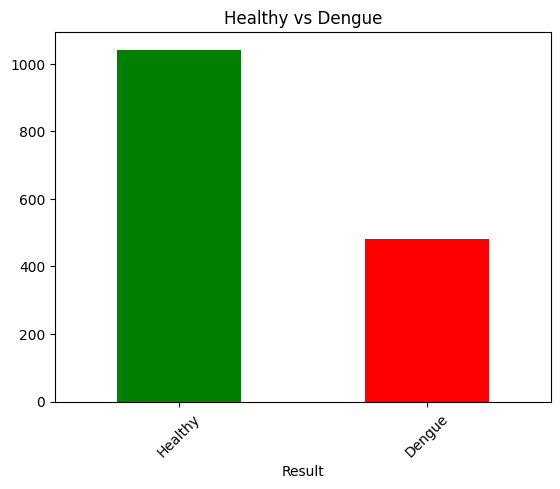

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from google.colab import files

# Show distribution
print(df['Result'].value_counts())

# Plot
df['Result'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Healthy vs Dengue')
plt.xticks([0, 1], ['Healthy', 'Dengue'], rotation=45)
plt.savefig('show distribution.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('show distribution.png')

In [12]:
from sklearn.preprocessing import LabelEncoder

# For yes/no or male/female (2 categories only)
label_encoder = LabelEncoder()

In [13]:
# Convert 'smoker' column
df['Result_encoded'] = label_encoder.fit_transform(df['Result'])
print("\nAfter Label Encoding 'Result':")
print(df[['Result', 'Result_encoded']])
# no = 0, yes = 1

# Convert 'gender' column
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])
print("\nAfter Label Encoding 'Gender':")
print(df[['Gender', 'Gender_encoded']])
# female = 0, male = 1


After Label Encoding 'Result':
        Result  Result_encoded
0     positive               1
1     positive               1
2     negative               0
3     negative               0
4     negative               0
...        ...             ...
1518  positive               1
1519  positive               1
1520  positive               1
1521  positive               1
1522  positive               1

[1523 rows x 2 columns]

After Label Encoding 'Gender':
      Gender  Gender_encoded
0       Male               1
1       Male               1
2       Male               1
3     Female               0
4       Male               1
...      ...             ...
1518  Female               0
1519    Male               1
1520    Male               1
1521    Male               1
1522    Male               1

[1523 rows x 2 columns]


In [16]:
#define a function called 'plot boxplot'
def plot_boxplot(df,ft):
    df.boxplot(column=ft)
    plt.grid(False)
    plt.show()

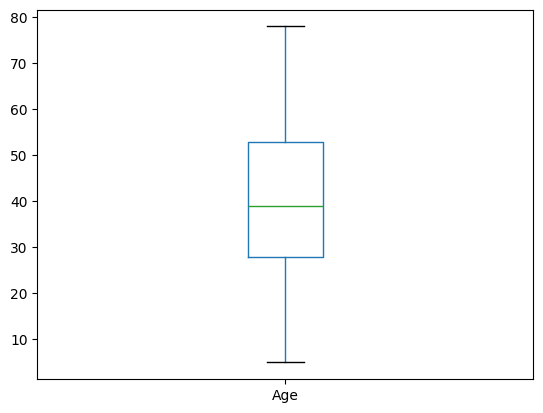

In [18]:
plot_boxplot(df,"Age")